In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

PROJECT_ROOT = Path("/Users/yimingzang/Documents/Project/benchmark2")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import bayesflow as bf
pd.set_option("display.max_columns", 100)

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
from benchmark.examples.diffusion.config import MODELS, RESULT_DIR, TrainingConfig, ensure_dirs
from benchmark.examples.diffusion.dataset import wagenmakers
from benchmark.examples.diffusion.simulators import SIMULATORS
from benchmark.examples.diffusion.approximators.indirect import load_approximator, load_history
from benchmark.examples.diffusion.results.results import (
    attach_gold_standard,
    estimate_model_comparison,
    load_results,
    save_results,
)
from benchmark.examples.diffusion.results.summary_diagnostic import (
    add_summary_diagnostics,
    fit_references,
    load_diagnostic,
    load_references,
    save_diagnostic,
    save_references,
)
from benchmark.examples.diffusion.results.plots import (
    plot_logml_error_vs_rho,
    plot_pmp_error_vs_log_ambiguity,
    plot_pmp_error_vs_rho,
    plot_pmp_estimates_vs_distance,
)

ensure_dirs()


In [3]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions

def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)

bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm


## 1. Load trained NPE approximators


In [4]:
config = TrainingConfig(epochs=50, batch_size=64, num_batches=64, summary_multiplier=4)
summary_tag = config.summary_label
results_path = RESULT_DIR / f"npe_{summary_tag}_results_gold.csv"
references_path = RESULT_DIR / f"npe_{summary_tag}_references.pkl"
diagnostic_path = RESULT_DIR / f"npe_{summary_tag}_empirical_diagnostic.csv"

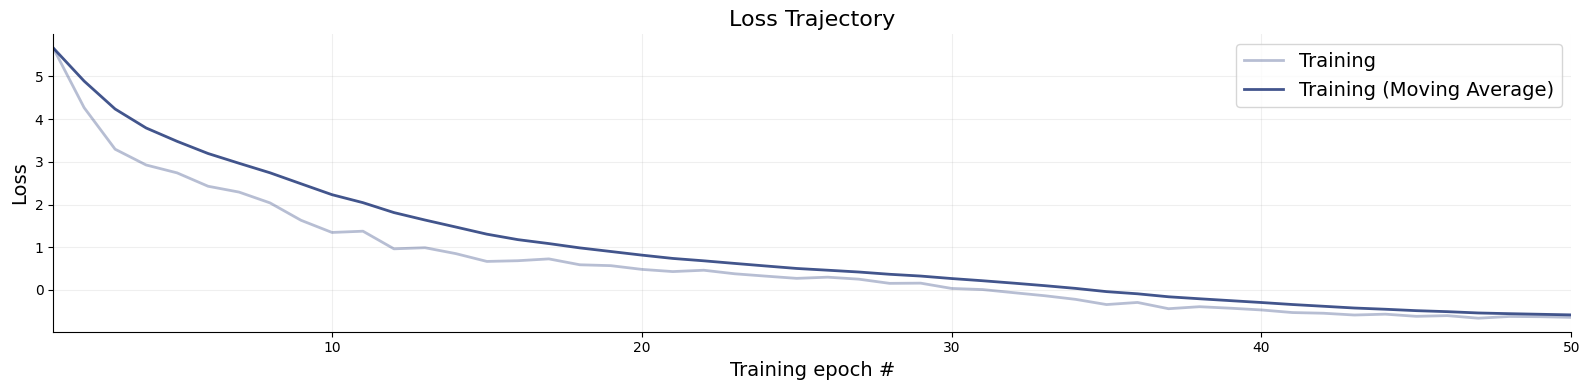

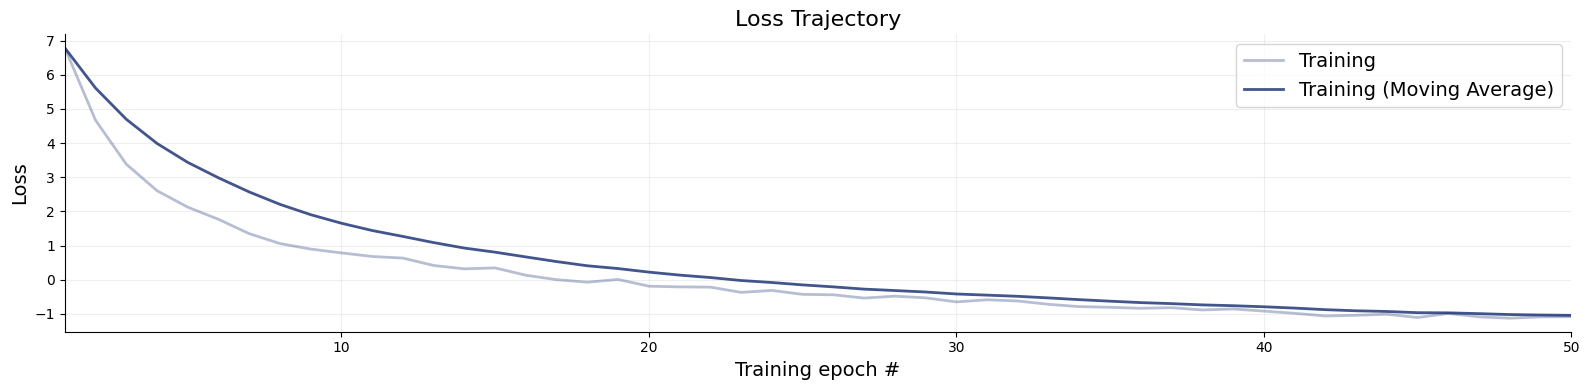

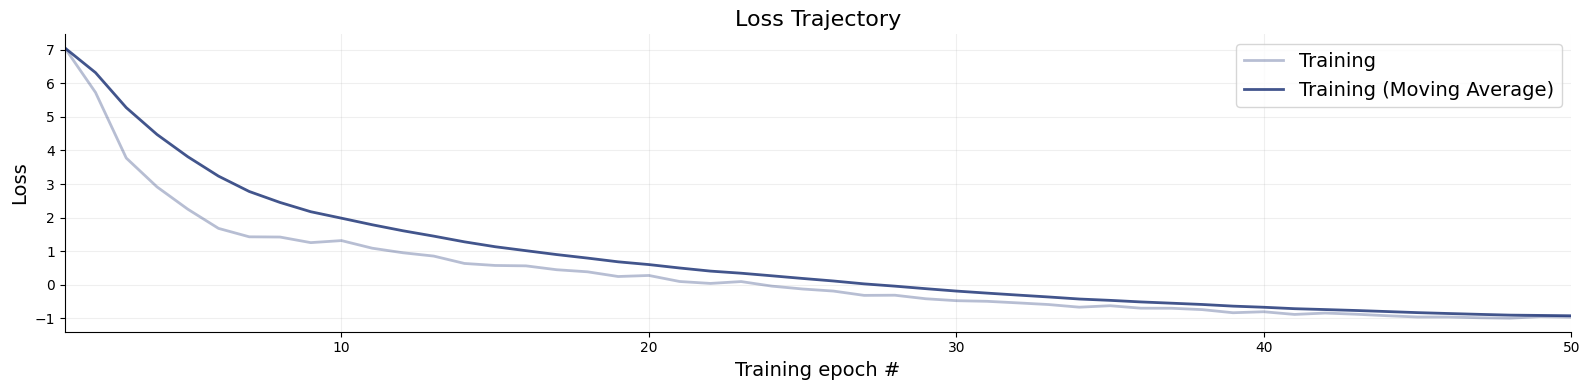

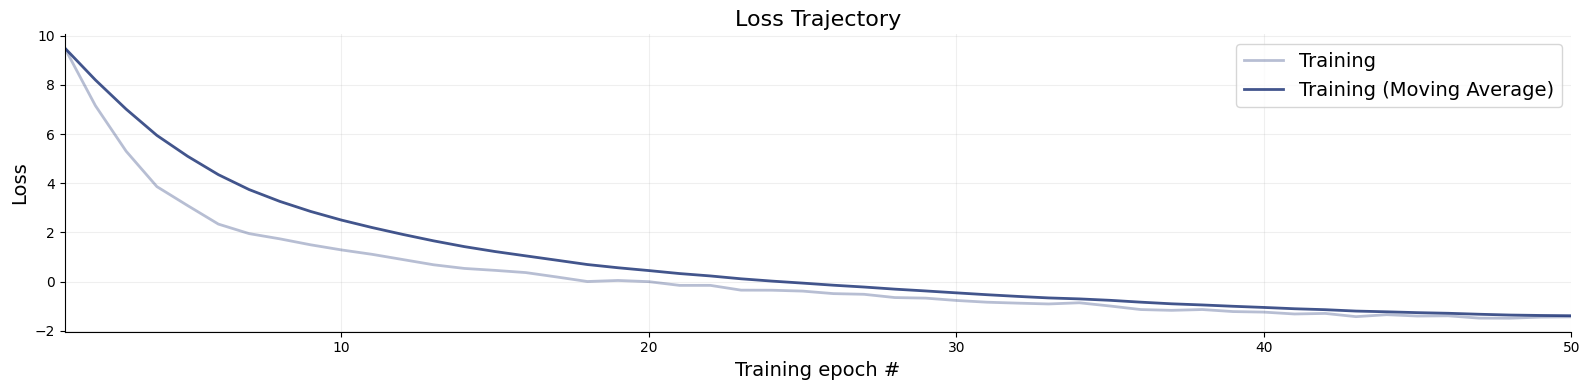

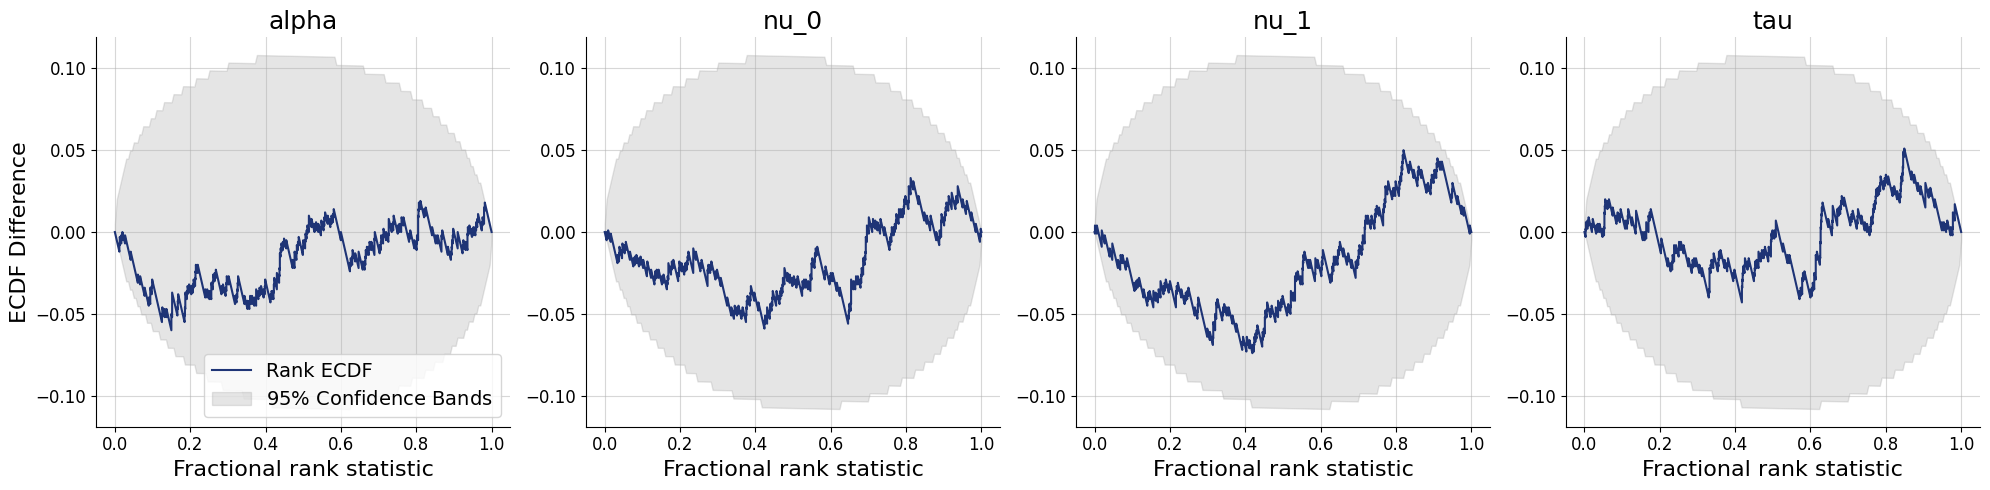

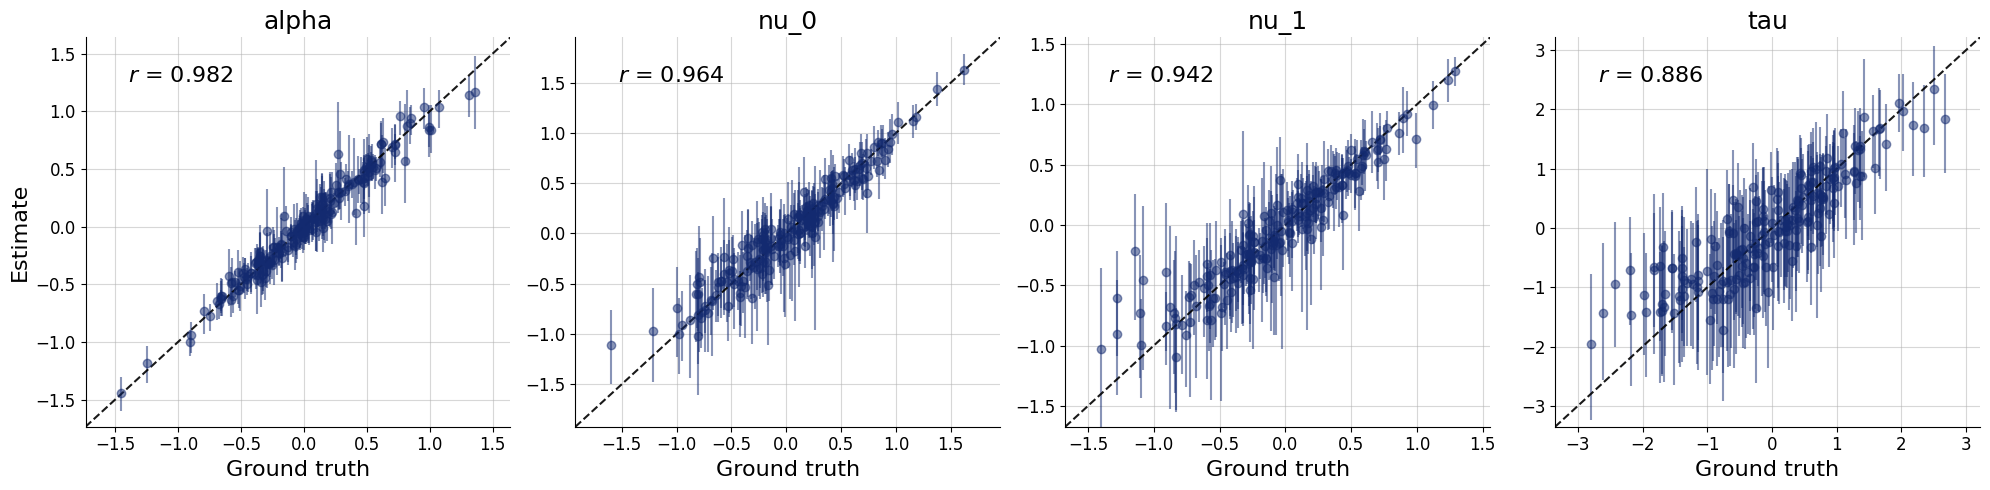

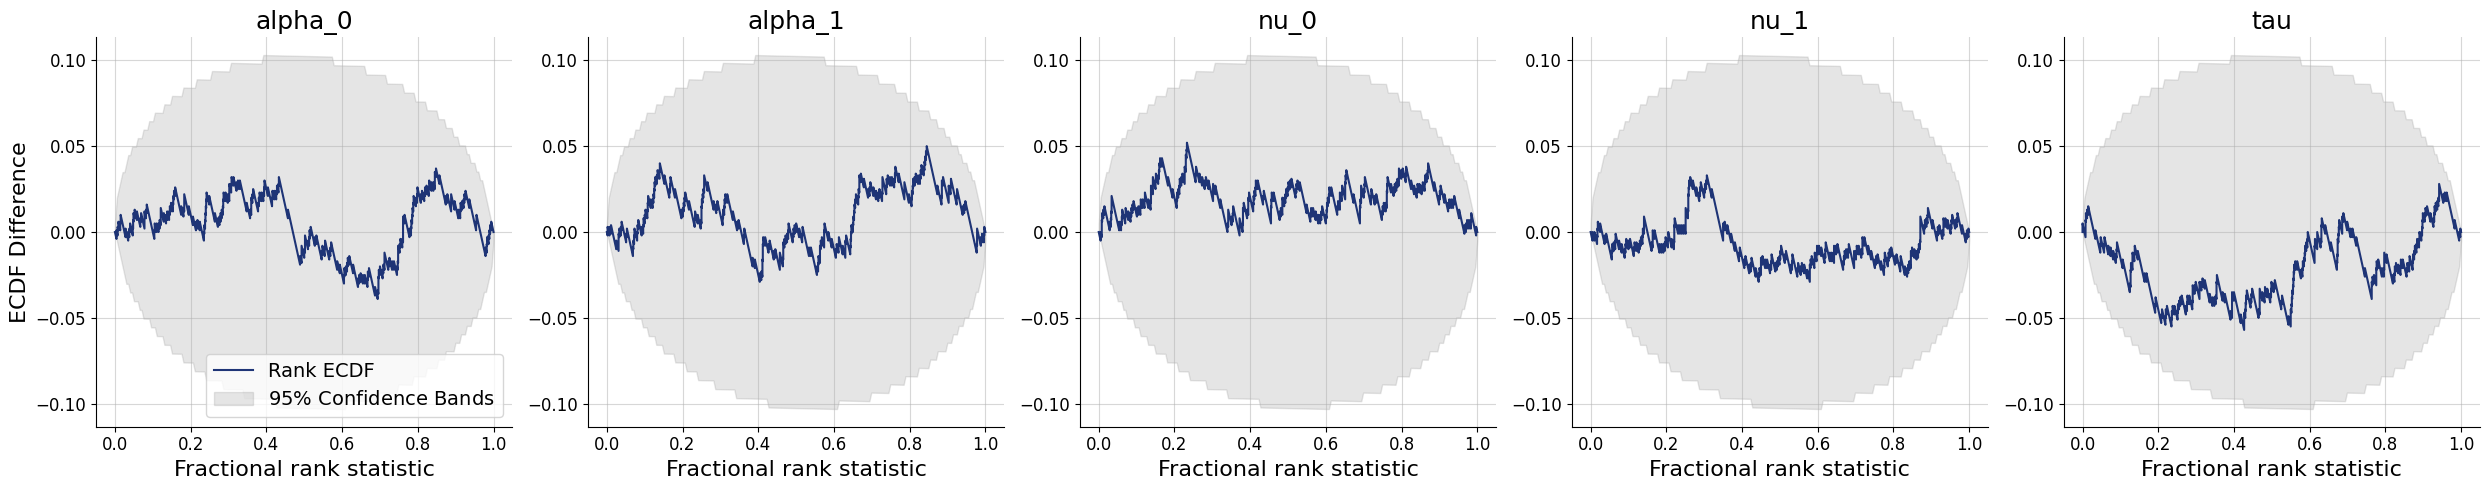

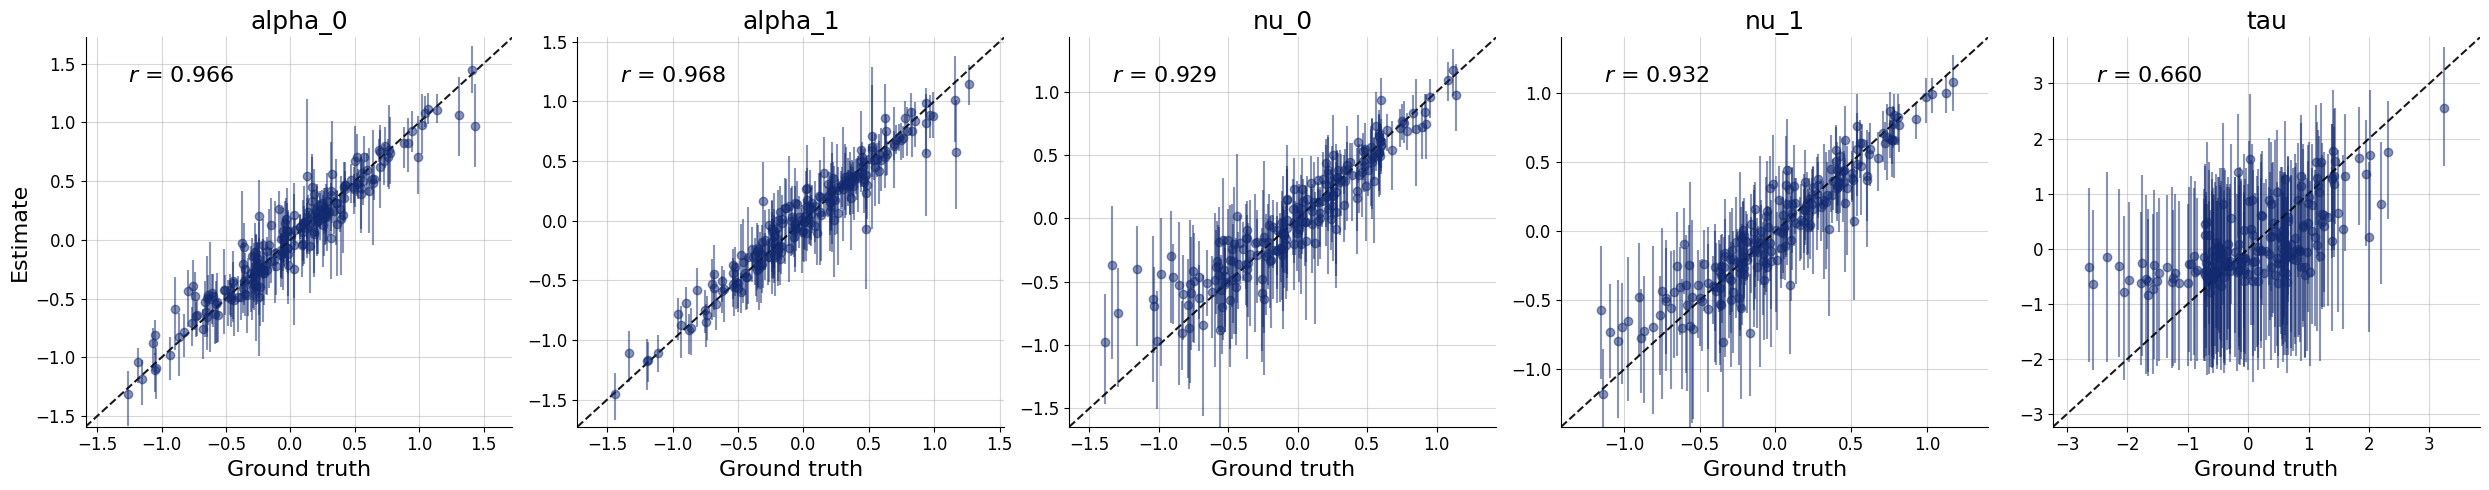

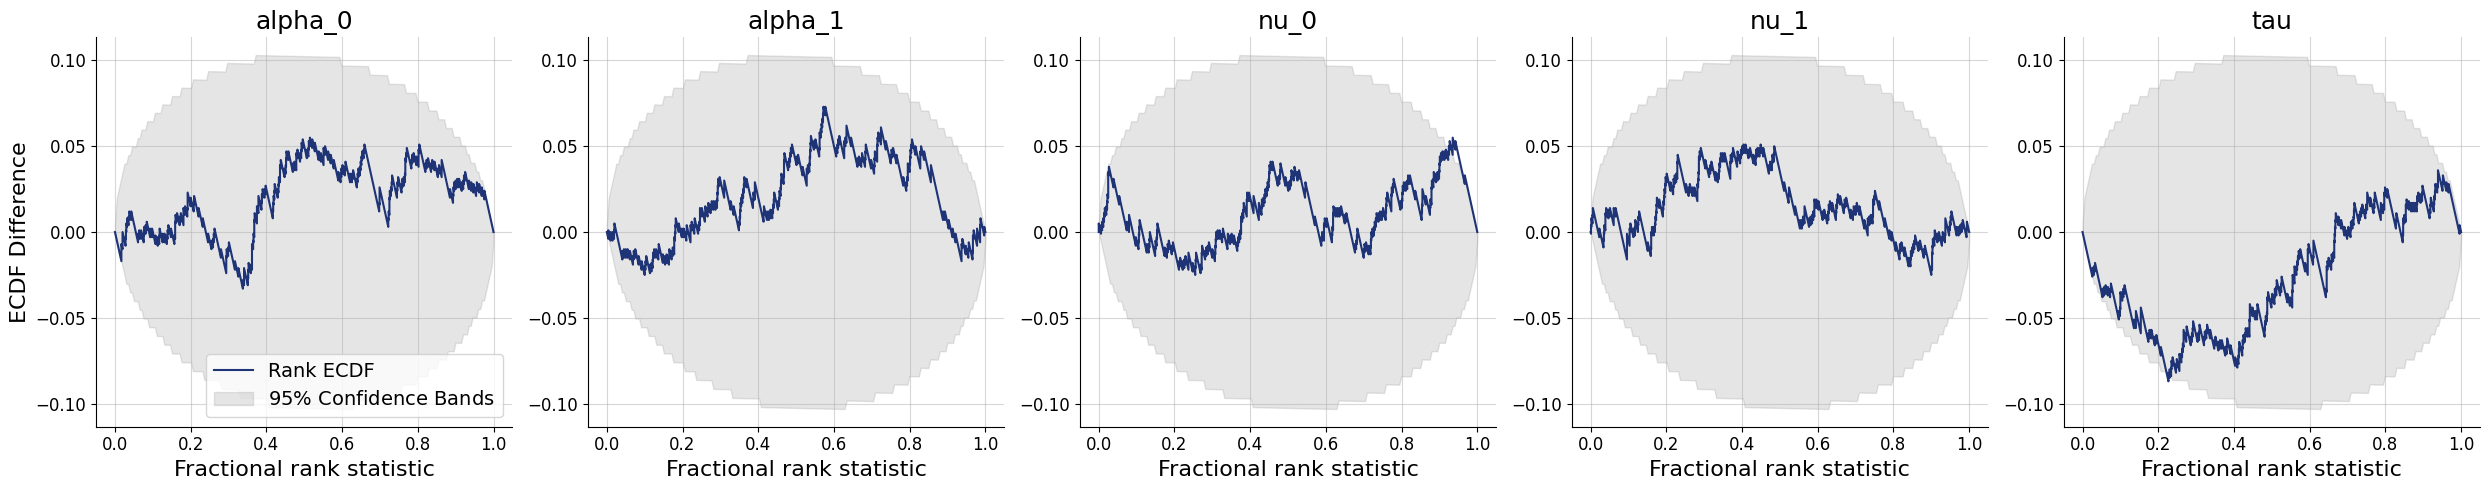

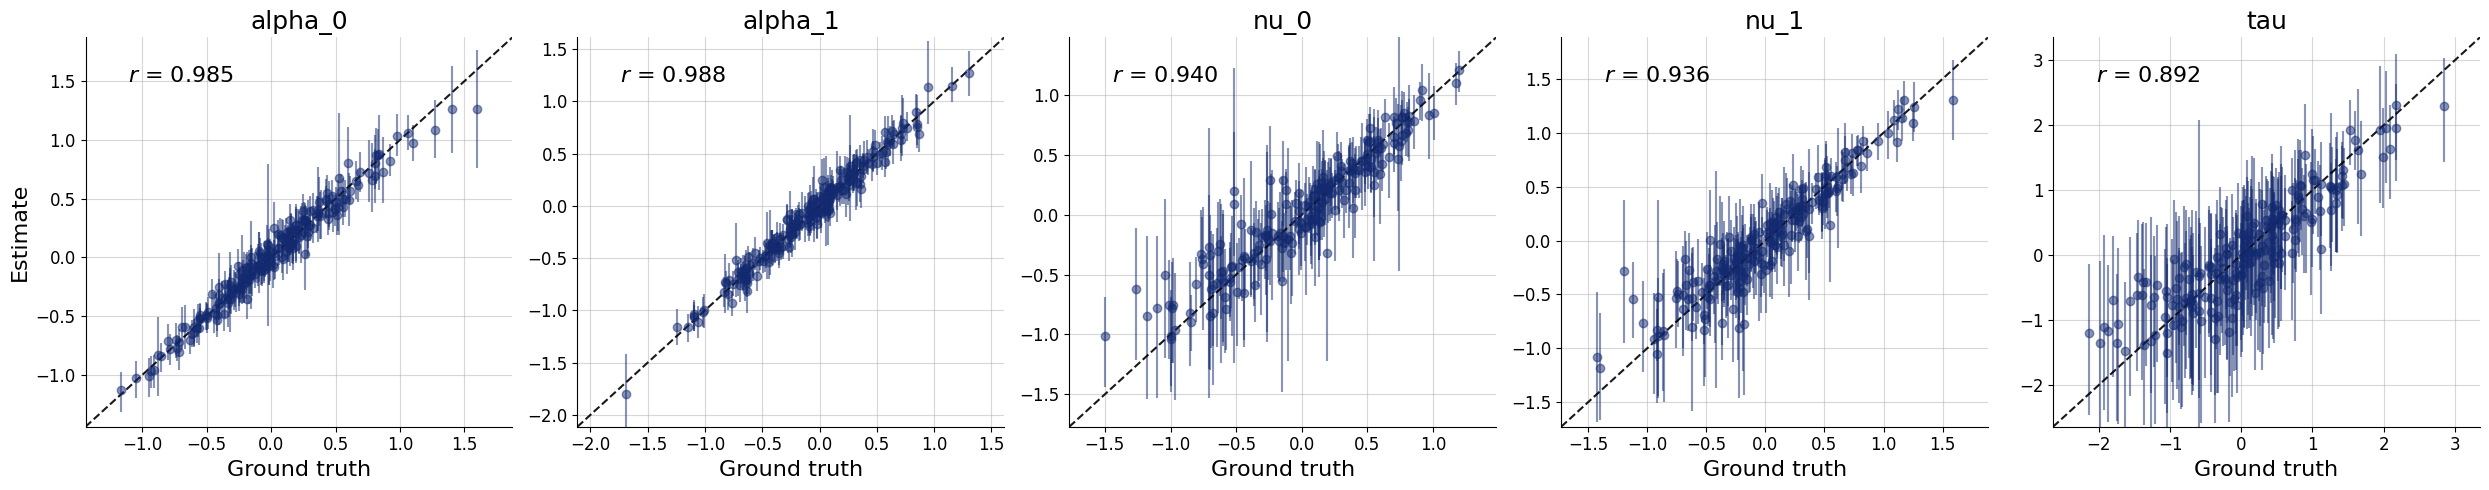

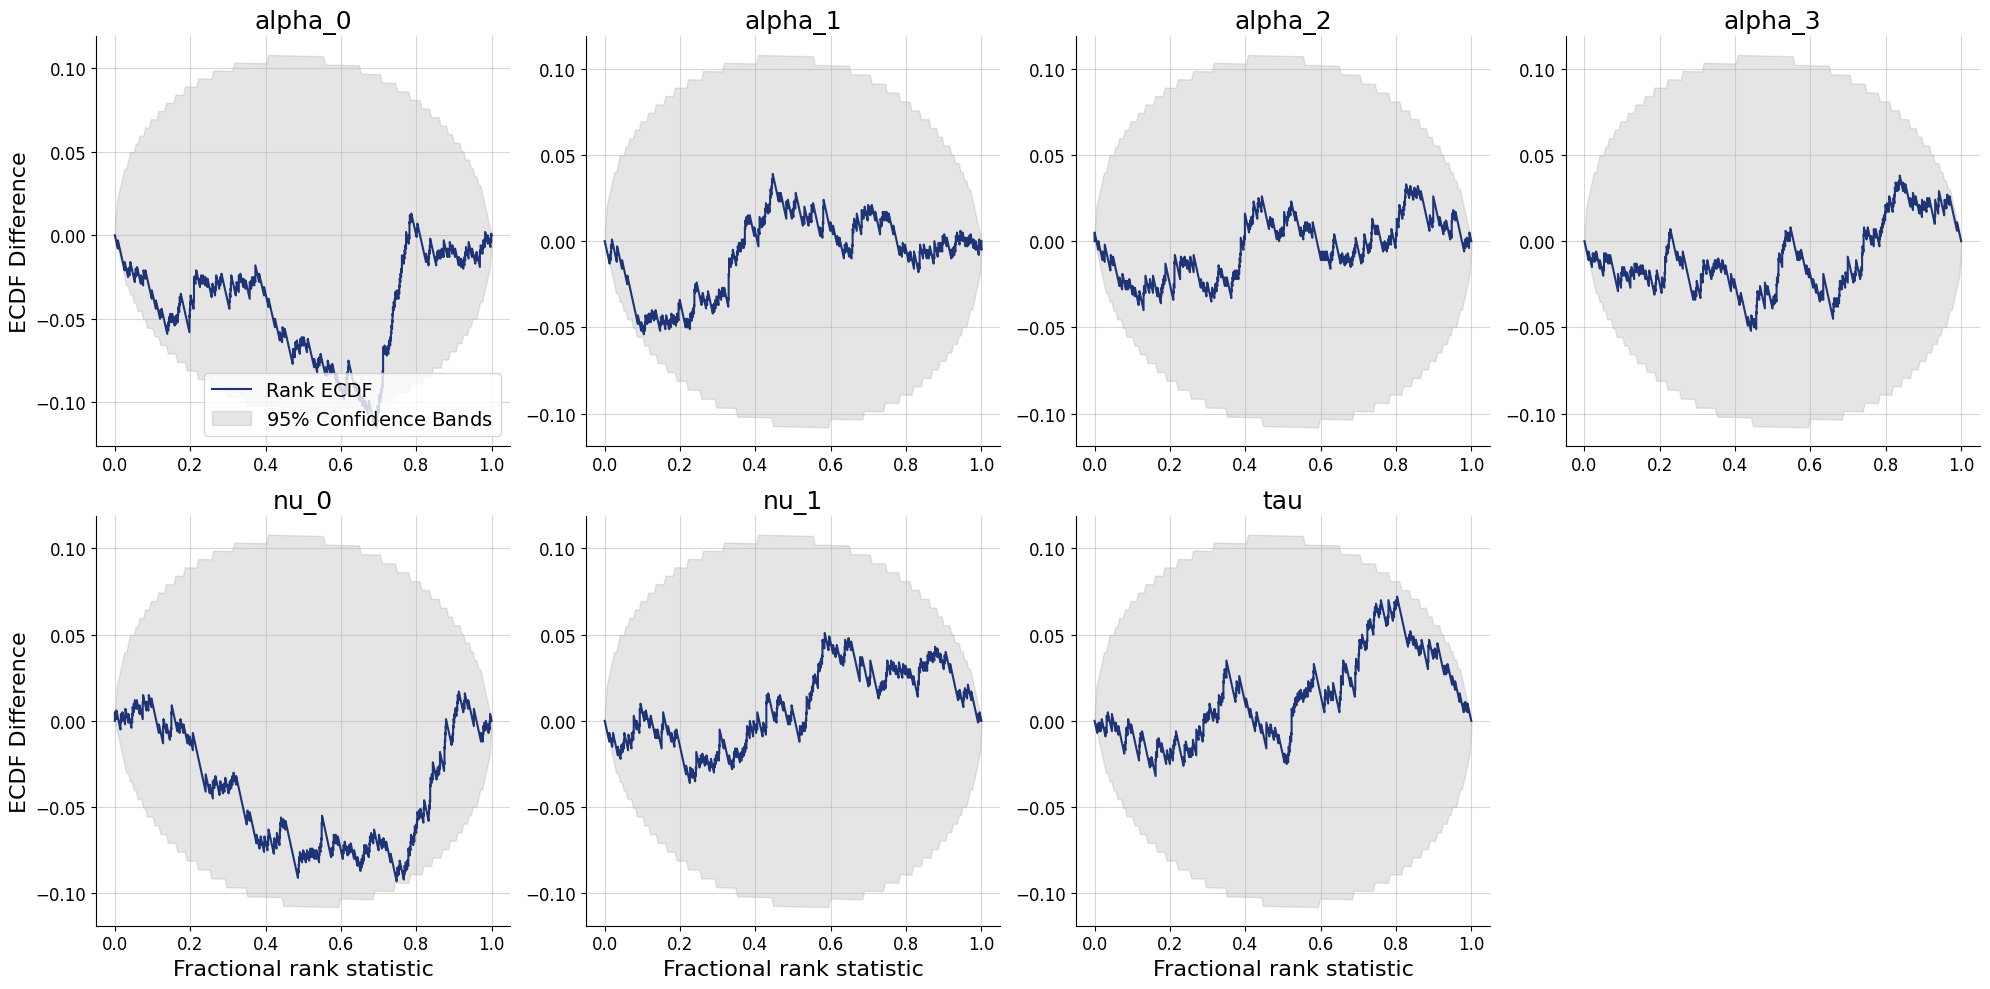

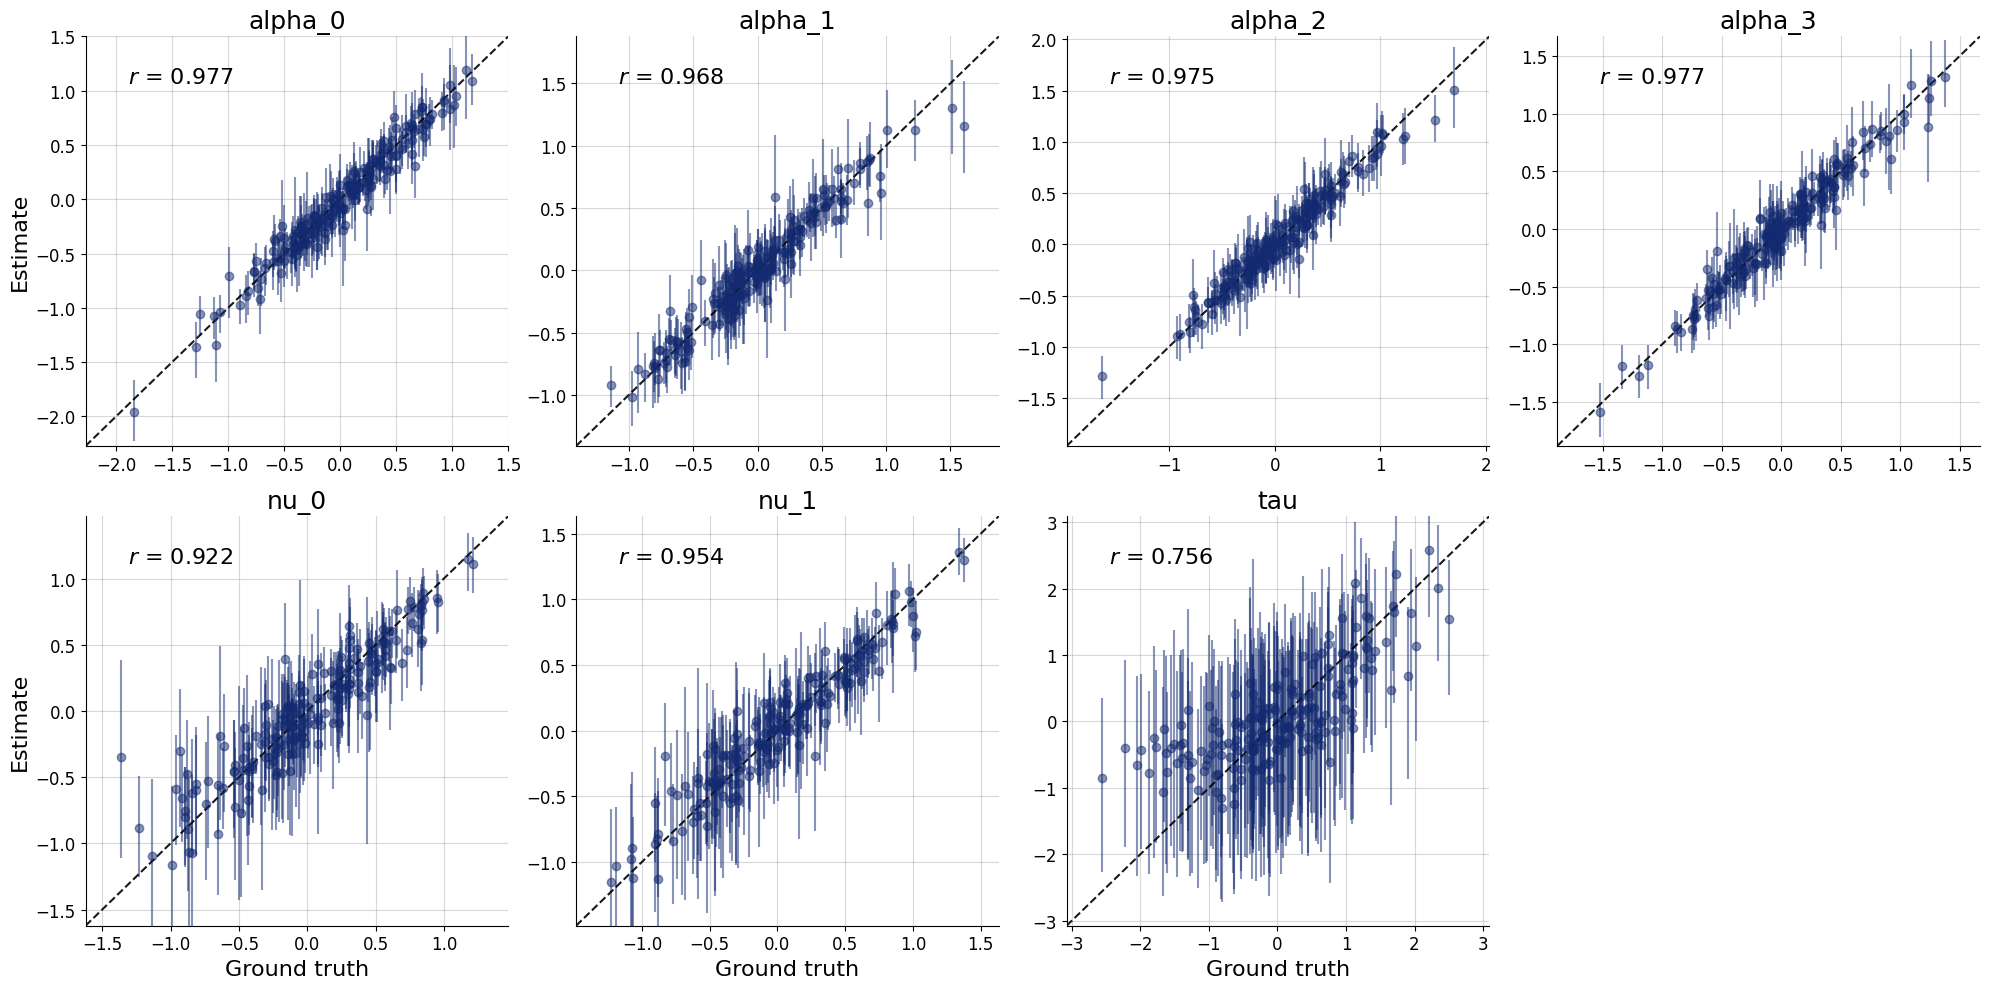

In [10]:
approximators = {model: load_approximator(model, config=config) for model in MODELS}
histories = {model: load_history(model, config=config) for model in MODELS}

for model in MODELS:
    bf.diagnostics.plots.loss(histories[model])

num_samples = 1000
for model in MODELS:
    val_sims = SIMULATORS[model].sample(200)
    post_draws = approximators[model].sample(conditions=val_sims, num_samples=num_samples)
    bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims, difference=True)
    bf.diagnostics.plots.recovery(post_draws, val_sims)


## 2. Load empirical datasets

In [11]:
empirical = wagenmakers.df_array
ids = wagenmakers.ids

empirical.shape, ids[:5]

((17, 384, 2), ['p0', 'p1', 'p2', 'p3', 'p4'])

## 3. Estimate NPE logML, logBF, and PMP

In [12]:
results = estimate_model_comparison(
    approximators,
    empirical,
    ids=ids,
    dataset="empirical",
    num_samples=2048,
    batch_size=8,
)

results_gold = attach_gold_standard(results)
save_results(results_gold, results_path)
results_gold.head()


,dataset,id,log_ml_m0,importance_ess_m0,log_ml_m1,importance_ess_m1,log_ml_m2,importance_ess_m2,log_ml_m3,importance_ess_m3,pmp_m0,pmp_m1,pmp_m2,pmp_m3,gold_log_ml_m0,gold_log_ml_m1,gold_log_ml_m2,gold_log_ml_m3,gold_pmp_m0,gold_pmp_m1,gold_pmp_m2,gold_pmp_m3,signed_logml_error_m0,signed_pmp_error_m0,abs_pmp_error_m0,signed_logml_error_m1,signed_pmp_error_m1,abs_pmp_error_m1,signed_logml_error_m2,signed_pmp_error_m2,abs_pmp_error_m2,signed_logml_error_m3,signed_pmp_error_m3,abs_pmp_error_m3
0,empirical,p0,73.403361,2.028838,89.309319,13.411654,70.938553,24.117133,84.608063,3.178859,1.225189e-07,0.990998,1.041719e-08,0.009002,71.808556,88.269208,69.808035,84.568990,6.928273e-08,9.758780e-01,9.371519e-09,0.024122,1.594805,5.323620e-08,5.323620e-08,1.040110,0.015120,0.015120,1.130518,1.045669e-09,1.045669e-09,0.039073,-0.015120,0.015120
1,empirical,p1,12.083164,8.238110,78.445255,1.723603,12.082297,20.367715,76.610759,5.144948,1.303067e-29,0.862296,1.301937e-29,0.137704,11.611132,78.260448,11.943984,79.133195,3.341374e-30,2.946830e-01,4.661018e-30,0.705317,0.472032,9.689295e-30,9.689295e-30,0.184807,0.567613,0.567613,0.138312,8.358353e-30,8.358353e-30,-2.522436,-0.567613,0.567613
2,empirical,p2,-11.270492,1.550812,38.616643,3.672095,4.531578,9.357921,49.494166,3.825504,4.076020e-27,0.000019,2.971584e-20,0.999981,-10.293330,37.335670,3.969435,57.456636,3.771930e-30,1.826314e-09,5.899348e-24,1.000000,-0.977161,4.072248e-27,4.072248e-27,1.280974,0.000019,0.000019,0.562143,2.970994e-20,2.970994e-20,-7.962470,-0.000019,0.000019
3,empirical,p3,168.937150,28.730843,195.473171,2.708879,167.515248,67.547091,196.167360,6.085940,9.957021e-13,0.333102,2.402180e-13,0.666898,167.837266,195.128890,166.361019,195.426395,5.983820e-13,4.261675e-01,1.367265e-13,0.573832,1.099884,3.973201e-13,3.973201e-13,0.344281,-0.093066,0.093066,1.154230,1.034915e-13,1.034915e-13,0.740965,0.093066,0.093066
4,empirical,p4,147.347476,197.106099,225.556569,16.741351,146.733460,85.136577,222.595931,2.261345,1.028715e-34,0.950764,5.567130e-35,0.049236,145.813723,223.169374,144.080511,219.278042,2.489368e-34,9.799904e-01,4.399109e-35,0.020010,1.533754,-1.460653e-34,1.460653e-34,2.387195,-0.029227,0.029227,2.652949,1.168021e-35,1.168021e-35,3.317888,0.029227,0.029227


## 4. Build summary-space typical sets

In [13]:
references = fit_references(
    approximators,
    SIMULATORS,
    n_fit=2000,
    n_calibration=2000,
    alpha=0.05,
    metric="l2",
    n_boot=1000,
)

save_references(references, references_path)
{model: {key: references[model][key] for key in ["summary_dim", "median", "low", "high"]} for model in references}


{'m0': {'summary_dim': 16,
  'median': 0.7019667286064873,
  'low': 0.4029847982788758,
  'high': 1.8889285933828643},
 'm1': {'summary_dim': 20,
  'median': 0.732415500775252,
  'low': 0.4393581718300157,
  'high': 1.8284278760501844},
 'm2': {'summary_dim': 20,
  'median': 0.7834458840489751,
  'low': 0.469169671389377,
  'high': 1.7416626468109253},
 'm3': {'summary_dim': 28,
  'median': 0.8112371453571201,
  'low': 0.4949985337094406,
  'high': 1.6959544938639792}}

## 5. Add summary diagnostics to empirical results

In [14]:
diagnostic = add_summary_diagnostics(results_gold, empirical, approximators, references)
save_diagnostic(diagnostic, diagnostic_path)

display_columns = (
    ["id"]
    + [f"rho_{model}" for model in MODELS]
    + [f"regime_{model}" for model in MODELS]
    + ["summary_ambiguity"]
    + [f"pmp_{model}" for model in MODELS]
    + [f"gold_pmp_{model}" for model in MODELS]
    + [f"abs_pmp_error_{model}" for model in MODELS]
)
diagnostic[display_columns].head(20)


,id,rho_m0,rho_m1,rho_m2,rho_m3,regime_m0,regime_m1,regime_m2,regime_m3,summary_ambiguity,pmp_m0,pmp_m1,pmp_m2,pmp_m3,gold_pmp_m0,gold_pmp_m1,gold_pmp_m2,gold_pmp_m3,abs_pmp_error_m0,abs_pmp_error_m1,abs_pmp_error_m2,abs_pmp_error_m3
0,p0,0.900063,0.771606,0.793467,0.630478,in_distribution,in_distribution,in_distribution,in_distribution,0.000000,1.225189e-07,9.909978e-01,1.041719e-08,0.009002,6.928273e-08,9.758780e-01,9.371519e-09,0.024122,5.323620e-08,1.511975e-02,1.045669e-09,1.511980e-02
1,p1,1.485805,1.002817,1.001252,1.121746,high surprise,high surprise,high surprise,high surprise,11.143980,1.303067e-29,8.622964e-01,1.301937e-29,0.137704,3.341374e-30,2.946830e-01,4.661018e-30,0.705317,9.689295e-30,5.676134e-01,8.358353e-30,5.676134e-01
2,p2,1.327775,0.888317,1.271548,1.134078,high surprise,in_distribution,high surprise,high surprise,0.000000,4.076020e-27,1.887747e-05,2.971584e-20,0.999981,3.771930e-30,1.826314e-09,5.899348e-24,1.000000,4.072248e-27,1.887564e-05,2.970994e-20,1.887564e-05
3,p3,1.271031,0.940663,0.975012,0.878500,high surprise,in_distribution,in_distribution,in_distribution,0.000000,9.957021e-13,3.331018e-01,2.402180e-13,0.666898,5.983820e-13,4.261675e-01,1.367265e-13,0.573832,3.973201e-13,9.306567e-02,1.034915e-13,9.306567e-02
4,p4,1.195349,0.953193,0.972155,0.819940,high surprise,in_distribution,in_distribution,in_distribution,0.000000,1.028715e-34,9.507639e-01,5.567130e-35,0.049236,2.489368e-34,9.799904e-01,4.399109e-35,0.020010,1.460653e-34,2.922653e-02,1.168021e-35,2.922653e-02
5,p5,1.093395,0.854224,0.887420,0.753883,high surprise,in_distribution,in_distribution,in_distribution,0.000000,4.052266e-16,2.185955e-01,1.274616e-14,0.781404,1.466121e-15,4.169979e-01,7.539907e-15,0.583002,1.060894e-15,1.984023e-01,5.206253e-15,1.984023e-01
6,p6,1.262129,0.654660,1.175797,0.657998,high surprise,in_distribution,high surprise,in_distribution,0.000000,8.121271e-10,7.031460e-06,3.742869e-02,0.962564,1.568121e-10,4.284786e-06,1.730393e-03,0.998265,6.553150e-10,2.746674e-06,3.569830e-02,3.570104e-02
7,p7,0.876657,0.790600,0.802445,0.792638,in_distribution,in_distribution,in_distribution,in_distribution,0.000000,5.086460e-54,8.086912e-01,6.229284e-55,0.191309,5.970915e-54,5.973384e-01,8.052601e-55,0.402662,8.844551e-55,2.113528e-01,1.823317e-55,2.113528e-01
8,p8,1.240499,0.794667,0.859395,0.859089,high surprise,in_distribution,in_distribution,in_distribution,0.000000,1.287229e-31,1.427578e-08,1.051048e-28,1.000000,1.810249e-31,7.591326e-05,1.027280e-28,0.999924,5.230200e-32,7.589898e-05,2.376814e-30,7.589898e-05
9,p9,1.336014,0.926996,0.987587,0.912320,high surprise,in_distribution,in_distribution,in_distribution,0.000000,2.774030e-15,2.220862e-02,4.878393e-12,0.977791,6.340414e-15,5.671474e-02,2.639804e-12,0.943285,3.566384e-15,3.450612e-02,2.238590e-12,3.450612e-02


## 6. Load cached tables for plotting

After the computations above have been saved once, you can restart the kernel and run this cell before plotting.


In [5]:
# Uncomment these lines to plot from saved results without recomputing logML or reference distances.
results_gold = load_results(results_path)
references = load_references(references_path)
diagnostic = load_diagnostic(diagnostic_path)


## 7. Basic plots


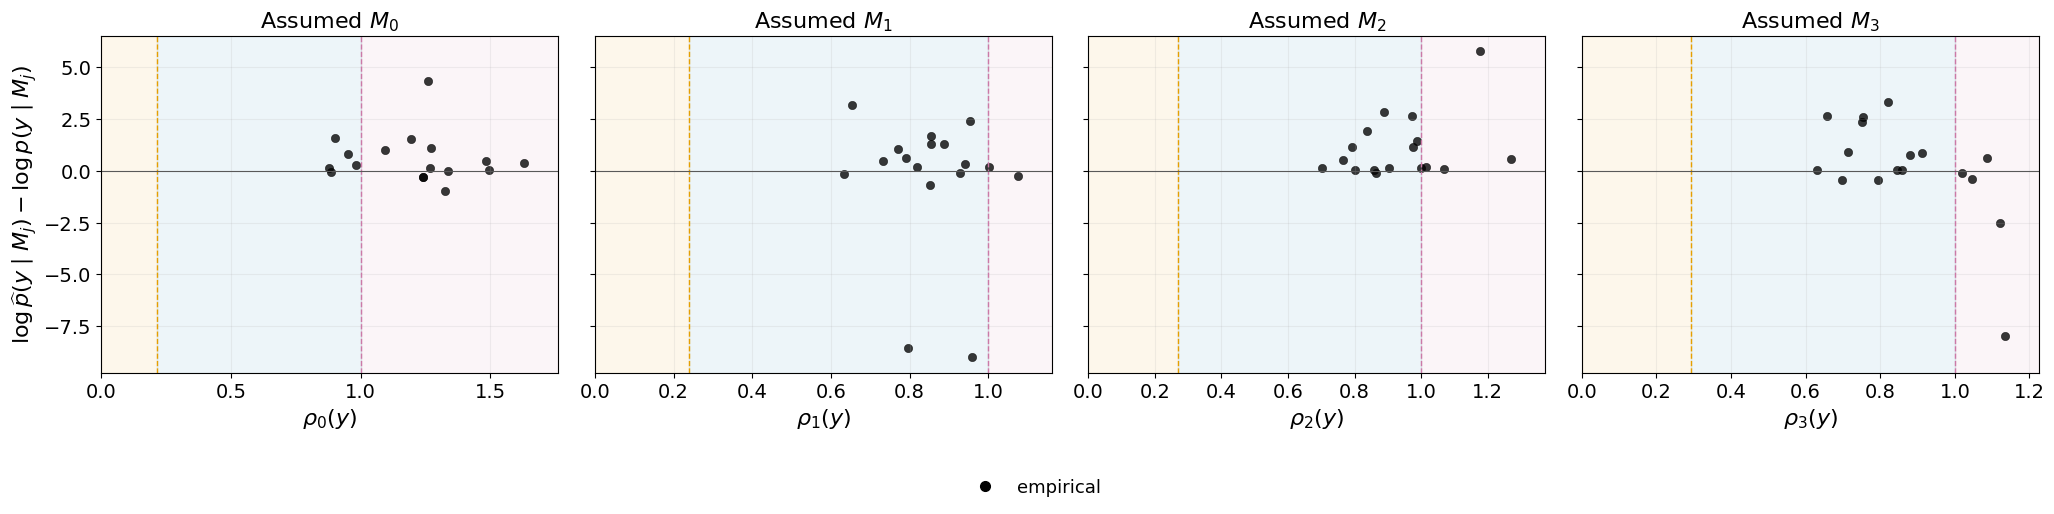

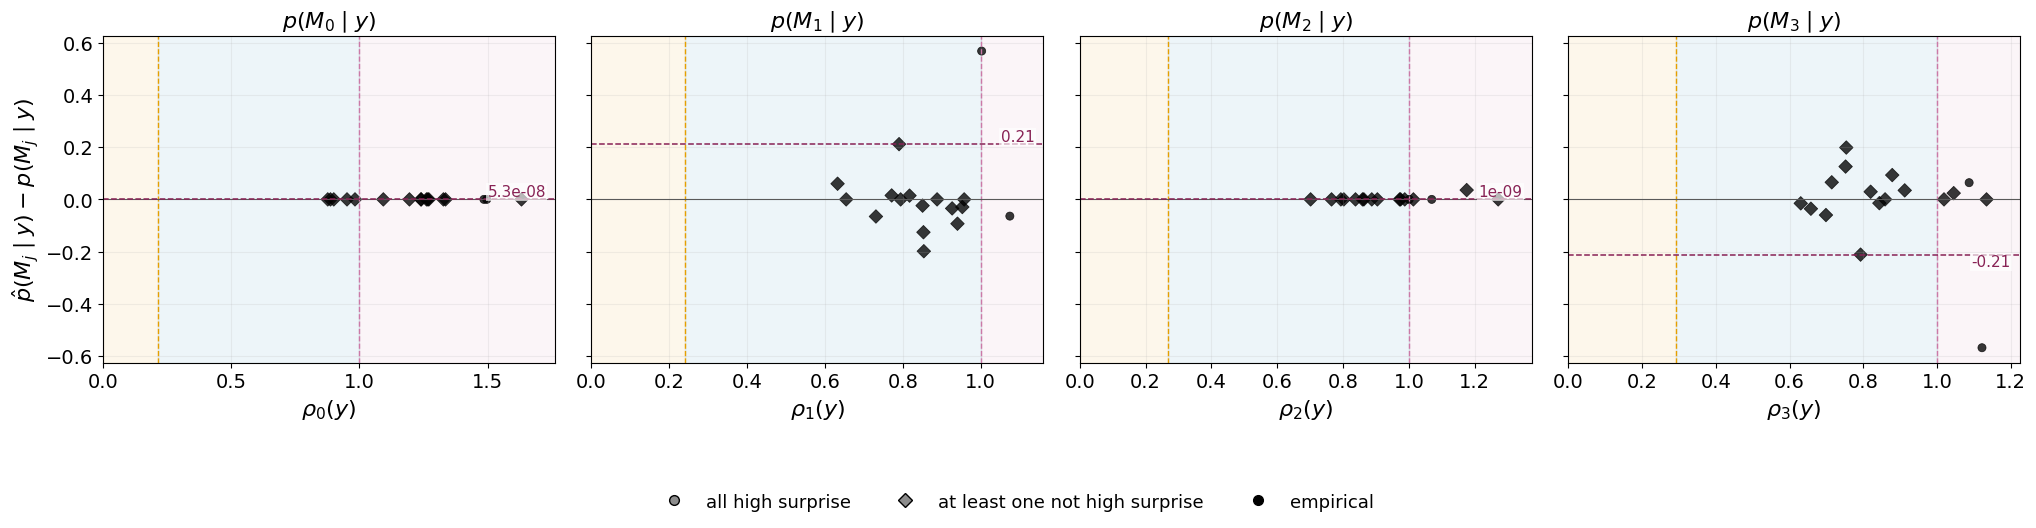

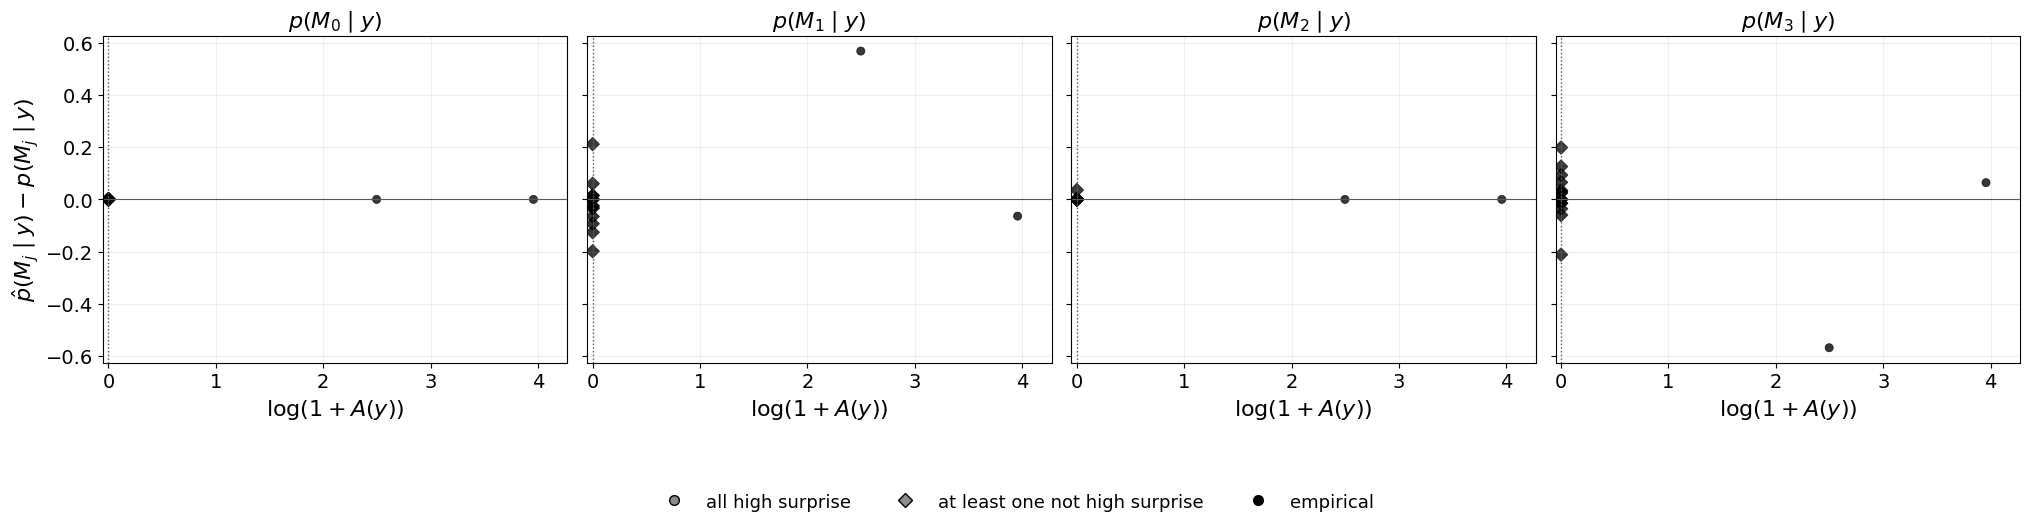

In [6]:
plot_logml_error_vs_rho(diagnostic, filename=f"npe_logml_error_vs_rho_{summary_tag}.png");
plot_pmp_error_vs_rho(diagnostic, filename=f"npe_pmp_error_vs_rho_{summary_tag}.png");
plot_pmp_error_vs_log_ambiguity(diagnostic, filename=f"npe_pmp_error_vs_log_ambiguity_{summary_tag}.png");


## 8. PMP Estimates vs Distance

Compare the NPE posterior model probability estimate with the Stan gold-standard PMP over summary distance.

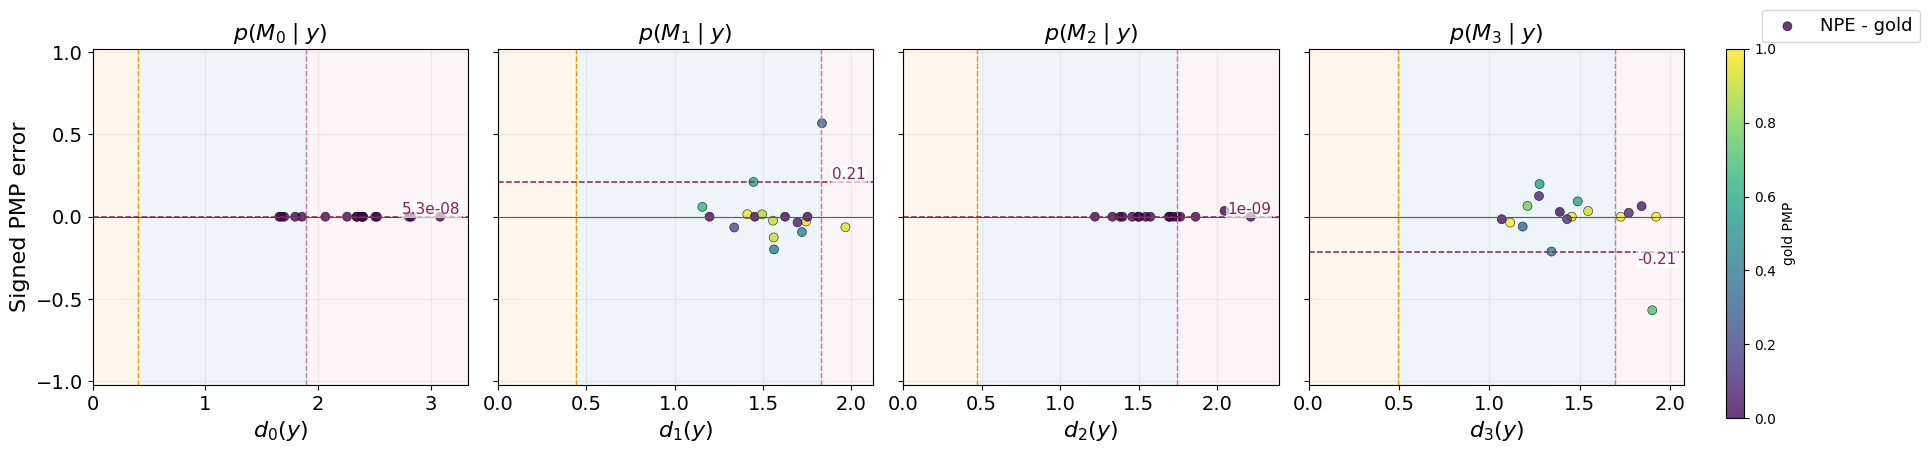

In [7]:
fig_pmp_signed_error_distance, axes_pmp_signed_error_distance = plot_pmp_estimates_vs_distance(
    diagnostic,
    x="distance",
    y="signed_pmp_error",
    filename=f"npe_pmp_signed_error_vs_distance_{summary_tag}.png",
)
